# Customer Churn Prediction using ANN

## Step 1 - Import Libraries
This cell imports all the required libraries for data handling, preprocessing, model building, evaluation, and saving the scaler/model.

In [2]:
import sys
print(sys.executable)

C:\Users\susha\Desktop\churn_tf_project\venv\Scripts\python.exe


In [3]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [5]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\susha\Desktop\churn_tf_project
['.ipynb_checkpoints', 'ChurnProject.ipynb', 'Churn_Modelling.csv', 'venv']


## Step 2 - Load the Dataset
This cell loads the `Churn_Modelling.csv` dataset into a pandas DataFrame and displays the first 5 rows.

In [6]:
df = pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Step 3 - Check Dataset Shape and Columns
This cell shows the number of rows and columns in the dataset and prints all column names.

In [7]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns)

Shape of dataset: (10000, 14)

Columns:
Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


## Step 4 - Check Dataset Information and Missing Values
This cell displays the data types of each column and checks whether the dataset contains any missing values.

In [8]:
df.info()
print("\nMissing values:\n")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

Missing values:

RowNumber          0
CustomerId         0
Surname            0
CreditScore  

## Step 5 - Drop Unnecessary Columns
This cell removes columns such as `RowNumber`, `CustomerId`, and `Surname` because they are not useful for churn prediction.

In [9]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Step 6 - Encode Categorical Columns
This cell converts categorical columns like `Geography` and `Gender` into numerical format using one-hot encoding.

In [10]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


## Step 7 - Separate Features and Target
This cell creates:
- `X` for input features
- `y` for the target variable `Exited`

In [11]:
X = df.drop(columns=['Exited'])
y = df['Exited']

## Step 8 - Check Input and Output Data
This cell verifies the shape of `X` and `y` and displays sample rows for confirmation.

In [12]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFirst 5 rows of X:")
print(X.head())
print("\nFirst 5 values of y:")
print(y.head())

X shape: (10000, 11)
y shape: (10000,)

First 5 rows of X:
   CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619   42       2       0.00              1          1   
1          608   41       1   83807.86              1          0   
2          502   42       8  159660.80              3          1   
3          699   39       1       0.00              2          0   
4          850   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  \
0               1        101348.88              False            False   
1               1        112542.58              False             True   
2               0        113931.57              False            False   
3               0         93826.63              False            False   
4               1         79084.10              False             True   

   Gender_Male  
0        False  
1        False  
2        False  
3        False  
4 

## Step 9 - Split the Dataset
This cell splits the dataset into training data and testing data using an 80:20 ratio.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 10 - Check Training and Testing Shapes
This cell confirms the number of rows and columns in training and testing data.

In [14]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 11)
X_test shape: (2000, 11)
y_train shape: (8000,)
y_test shape: (2000,)


## Step 11 - Perform Feature Scaling
This cell standardizes the input features using `StandardScaler` so that the ANN can train efficiently.

In [15]:
scaler = StandardScaler()

X_train_trf = scaler.fit_transform(X_train)
X_test_trf = scaler.transform(X_test)

## Step 12 - Build the ANN Model
This cell creates the Artificial Neural Network using:
- two hidden layers
- one output layer

In [16]:
model = Sequential()

model.add(Dense(11, activation='sigmoid', input_dim=X_train_trf.shape[1]))
model.add(Dense(11, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

C:\Users\susha\Desktop\churn_tf_project\venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Step 13 - Display Model Summary
This cell shows the ANN architecture, including layer details and total trainable parameters.

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              12 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

## Step 14 - Compile the Model
This cell configures the ANN using:
- Adam optimizer
- Binary crossentropy loss
- Accuracy as the evaluation metric

In [18]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

## Step 15 - Train the Model
This cell trains the ANN on the scaled training data and stores the training history for later plotting.

In [19]:
history = model.fit(
    X_train_trf,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7934 - loss: 0.5244 - val_accuracy: 0.7987 - val_loss: 0.4932
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7934 - loss: 0.4934 - val_accuracy: 0.7987 - val_loss: 0.4733
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7934 - loss: 0.4720 - val_accuracy: 0.7987 - val_loss: 0.4494
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7934 - loss: 0.4521 - val_accuracy: 0.7987 - val_loss: 0.4320
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7959 - loss: 0.4396 - val_accuracy: 0.8081 - val_loss: 0.4231
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8069 - loss: 0.4336 - val_accuracy: 0.8244 - val_loss: 0.4188
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8111 - loss: 0.4307 - val_accuracy: 0.8275 - val_loss: 0.4167
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8136 - loss: 0.4289 - val_accu

## Step 16 - Predict on Test Data
This cell predicts churn probabilities for the test dataset.

In [20]:
y_pred = model.predict(X_test_trf)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


## Step 17 - Convert Probabilities into Final Classes
This cell converts predicted probabilities into final class labels:
- `1` for churn
- `0` for stay

In [21]:
y_pred = (y_pred > 0.5).astype(int)
y_pred = y_pred.flatten()

## Step 18 - Calculate Accuracy
This cell computes the accuracy of the model on the test data.

In [22]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.861


## Step 19 - Display Confusion Matrix
This cell prints the confusion matrix to compare actual and predicted churn values.

In [23]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[1544   63]
 [ 215  178]]


## Step 20 - Display Classification Report
This cell prints precision, recall, F1-score, and support for model evaluation.

In [24]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.74      0.45      0.56       393

    accuracy                           0.86      2000
   macro avg       0.81      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



## Step 21 - Plot Training and Validation Loss
This cell plots the training loss and validation loss to understand model learning behavior.

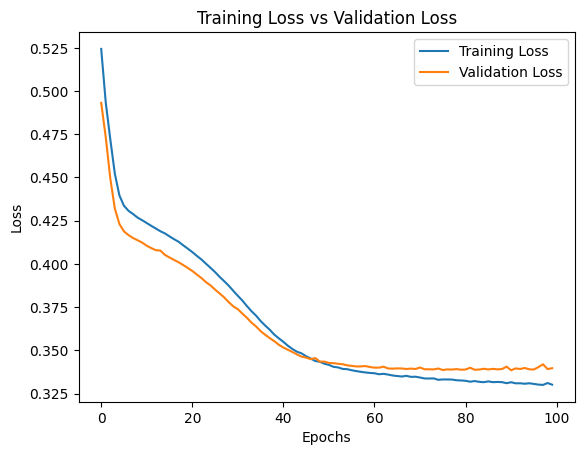

In [25]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Training Loss vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Training Loss', 'Validation Loss'])
plt.show()

## Step 22 - Plot Training and Validation Accuracy
This cell plots the training accuracy and validation accuracy across epochs.

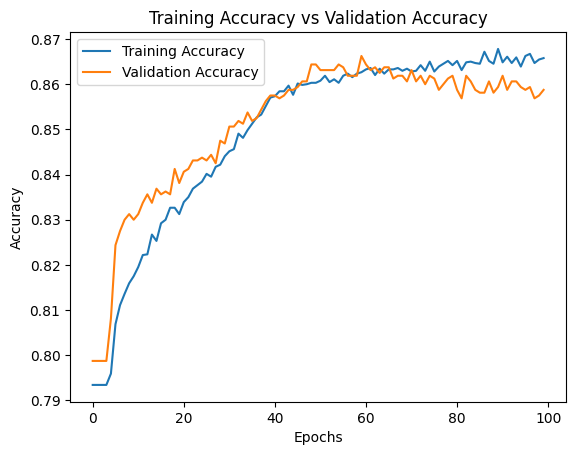

In [26]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Training Accuracy vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.show()

## Step 23 - Predict for One New Customer
This cell predicts churn probability for a custom customer and prints the final prediction in a user-friendly format.

In [27]:
y_pred = model.predict(X_test_trf)
y_pred = (y_pred > 0.5).astype(int).flatten()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [28]:
new_customer = pd.DataFrame([{
    'CreditScore': 600,
    'Age': 40,
    'Tenure': 3,
    'Balance': 60000.0,
    'NumOfProducts': 2,
    'HasCrCard': 1,
    'IsActiveMember': 1,
    'EstimatedSalary': 50000.0,
    'Geography_Germany': 1,
    'Geography_Spain': 0,
    'Gender_Male': 1
}])

new_customer_trf = scaler.transform(new_customer)
prediction = model.predict(new_customer_trf)
print("Prediction probability:", prediction)
print("Final prediction:", (prediction > 0.5).astype(int))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Prediction probability: [[0.04485035]]
Final prediction: [[0]]


## Step 24 - Create a Reusable Prediction Function
This cell defines a function named `predict_churn()` so that churn can be predicted easily for any new customer input.

In [32]:
import pandas as pd

def predict_churn(customer_data):
    new_customer = pd.DataFrame([customer_data])
    new_customer_trf = scaler.transform(new_customer)
    prediction = model.predict(new_customer_trf, verbose=0)

    churn_prob = float(prediction[0][0])

    print(f"Churn Probability: {churn_prob:.2f}")

    if churn_prob > 0.5:
        print("Final Prediction: Customer will churn")
    else:
        print("Final Prediction: Customer will stay")

## Step 25 - Test the Reusable Function
This cell uses sample customer data to test the `predict_churn()` function.

In [30]:
customer_1 = {
    'CreditScore': 600,
    'Age': 40,
    'Tenure': 3,
    'Balance': 60000.0,
    'NumOfProducts': 2,
    'HasCrCard': 1,
    'IsActiveMember': 1,
    'EstimatedSalary': 50000.0,
    'Geography_Germany': 1,
    'Geography_Spain': 0,
    'Gender_Male': 1
}

predict_churn(customer_1)

Churn Probability: 0.04
Final Prediction: Customer will stay


## Step 26 - Save the Trained Model
This cell saves the trained ANN model so it can be reused later without training again.

In [33]:
model.save("customer_churn_ann_model.h5")

## Step 27 - Save the Scaler
This cell saves the fitted `StandardScaler` object so that new customer data can be scaled in the same way later.

In [34]:
import pickle

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

## Step 28 - Load the Saved Model and Scaler
This cell reloads the saved ANN model and scaler from disk for future predictions.

In [35]:
from tensorflow.keras.models import load_model
import pickle

model = load_model("customer_churn_ann_model.h5")

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# Conclusion
This project successfully predicts customer churn using an Artificial Neural Network built with TensorFlow and Keras. The dataset was preprocessed, categorical values were encoded, numerical features were scaled, and the ANN model was trained and evaluated using standard classification metrics. The final model can also predict churn probability for new customer data.

## Objective
The objective of this project is to predict whether a bank customer will leave the bank or stay, based on customer details such as credit score, age, balance, products used, activity status, and geography.